In [ ]:
import yfinance as yf
import pandas as pd
import io

In [ ]:
try:
    tickers = ['AEO', 'TJX', 'DDS', 'GAP','URBN','WSM', "WMT", "TGT", "BBY", "ROST", "M", "NKE", "ULTA", "DKS", "RL", "BBWI", "BURL", "DLTR" ]
    start_date = '2015-01-01'

    adj_close_prices = yf.download(tickers, start=start_date)['Close']
    adj_close_prices.dropna(axis=1, how='all', inplace=True)

    if adj_close_prices.empty:
        print("no data")
    else:
        monthly_returns = adj_close_prices.resample('BME').last().pct_change()
        monthly_returns.dropna(inplace=True)
        monthly_returns['Portfolio_Return'] = monthly_returns.mean(axis=1)

        print("\n Monthly Portfolio Returns")
        print(monthly_returns.head())


        ff_data_string = """
            Mkt-RF	SMB	HML	RF
201501	-1.74	0.02	-2.49	0
201502	5.91	-0.34	-0.3	0
201503	-1.17	1.41	-0.8	0
201504	2.71	0.86	2.27	0
201505	0.5	1.22	-1.12	0
201506	-2.09	2.1	-0.66	0
201507	1.13	-3.08	-3.25	0
201508	-6.18	1.15	1.27	0
201509	-3.91	-0.18	-1.02	0
201510	7.32	-2.4	0.34	0
201511	-0.3	1.72	-1.99	0
201512	-1.73	1.01	-1.7	0.01
201601	-6.32	-2.11	0.76	0.01
201602	-0.5	0.83	-0.21	0.02
201603	6.92	1.32	0.42	0.02
201604	1.91	1.12	2.98	0.01
201605	0.45	0.02	-2.11	0.01
201606	-1.67	-0.49	-0.73	0.02
201607	4.48	1.28	0.46	0.02
201608	0.29	0.3	2.19	0.02
201609	0.9	2.32	-1.23	0.02
201610	-1.88	-1.47	4.09	0.02
201611	1.39	0.25	4.39	0.01
201612	2.25	-0.48	2.76	0.03
201701	2.72	0.4	-0.53	0.04
201702	2.28	-0.6	-1.74	0.04
201703	1.48	0.3	-1.81	0.03
201704	1.86	0.36	-1.39	0.05
201705	2.2	-0.43	-2.59	0.06
201706	0.6	1.67	1.74	0.06
201707	2.51	-0.05	1.02	0.07
201708	0.13	-0.14	-1.34	0.09
201709	2.3	1.27	1.64	0.09
201710	1.8	-0.87	-0.9	0.09
201711	1.93	-0.71	-0.13	0.08
201712	1.38	0.9	0.11	0.09
201801	5.15	-1.05	-1.43	0.11
201802	-4	0.82	-1.79	0.11
201803	-1.76	1.23	-0.42	0.12
201804	0.93	-0.54	1.76	0.14
201805	0.49	1.88	-4.52	0.14
201806	-0.49	-0.69	-1.39	0.14
201807	2.53	-2.52	1.19	0.16
201808	0.87	-0.5	-4.19	0.16
201809	0.32	-1.49	0.3	0.15
201810	-8.19	-2.53	2.44	0.19
201811	0.88	-0.51	-1.22	0.18
201812	-7.67	-1.01	0.56	0.19
201901	7.47	-0.09	-0.71	0.21
201902	2.94	0.23	-2.09	0.18
201903	0.76	-1.84	-3.28	0.19
201904	3.44	-1.25	-0.26	0.21
201905	-5.99	0.67	-1.7	0.21
201906	6.13	-1.98	-0.17	0.18
201907	-0.07	-1.08	-0.63	0.19
201908	-2.55	-1.4	-2.7	0.16
201909	1.9	-0.48	4.15	0.18
201910	2.56	0.81	-0.53	0.15
201911	2.74	0.32	-2.22	0.12
201912	3.05	1.27	0.62	0.14
202001	-1.2	-2.16	-4.33	0.13
202002	-8.54	-1.23	-1.07	0.12
202003	-13.77	-3.29	-9.3	0.12
202004	10.68	2.34	-4.62	0
202005	5.3	2.65	-5.1	0.01
202006	2.76	0.19	-1.73	0.01
202007	4.34	-1.26	-3.64	0.01
202008	6.84	1.45	-3.88	0.01
202009	-2.99	2.39	-2.46	0.01
202010	-2.6	1.21	2.04	0.01
202011	13.34	0.67	4.34	0.01
202012	4.82	3.31	-1.2	0.01
202101	-0.54	2.97	1.01	0
202102	2.88	0.43	7.46	0
202103	3.12	-2.34	5.58	0
202104	4.49	-1.04	-1.97	0
202105	1.65	-0.44	4.14	0
202106	1.01	-0.29	-5.23	0
202107	1.04	-2.31	-1.67	0
202108	2.42	0.1	-1.71	0
202109	-3.81	0.77	3.86	0
202110	5.04	-3.29	-1.48	0
202111	-2.64	-2.06	-2.21	0
202112	3.63	-1.77	3.9	0.01
202201	-5.58	-4.16	11.96	0
202202	-2.25	1.75	2.89	0
202203	2.16	-1.82	-1.1	0
202204	-8.17	-0.31	4.95	0
202205	0.28	-1.21	6.14	0.03
202206	-8.69	-0.08	-1.41	0.06
202207	7.79	0.27	-5.48	0.08
202208	-4.22	0.42	2.49	0.19
202209	-9.46	-1.66	1.89	0.19
202210	6.79	-2.02	4.41	0.23
202211	7.25	-0.24	-0.28	0.29
202212	-4.33	2.14	2.51	0.33
202301	6.92	0.98	-1.89	0.35
202302	-2.67	-0.04	0.69	0.34
202303	2.27	-3.23	-6.92	0.36
202304	1.22	-1.75	1	0.35
202305	-1.61	-0.66	-4.76	0.36
202306	5.6	-1.58	1.04	0.4
202307	2.96	0.74	3.43	0.45
202308	-3.06	-1.74	-0.36	0.45
202309	-4.79	-1.36	3.3	0.43
202310	-3.76	-2.8	0.36	0.47
202311	8.63	-0.41	-1.68	0.44
202312	4.97	3.52	1.11	0.43
202401	0.09	-3.51	-0.03	0.47
202402	3.75	-2.3	-1.35	0.42
202403	2.87	-1.14	4.06	0.43
202404	-4.19	-0.93	1.33	0.47
202405	4.05	0.25	-0.95	0.44
202406	0.83	-2.42	-4.46	0.41
202407	1.81	3.85	3.36	0.45
202408	1.83	-1.98	-1.93	0.48
202409	1.51	0.13	-0.71	0.4
202410	-2.47	-2.09	1.29	0.39
202411	4.08	-0.79	0.61	0.4
202412	-3.15	-0.9	-2.21	0.37
202501	3.22	-1.49	0.82	0.37
202502	-1.22	-1.96	3.75	0.33
202503	-4.35	1.66	4.43	0.34
202504	0.87	2.28	-3.29	0.35
202505	5.57	0.02	-1.46	0.38
202506	4.1	0.48	0.01	0.34
202507	0.68	-0.44	-0.1	0.35
202508	2.64	2.52	2.88	0.38
        """

        factors_df = pd.read_csv(io.StringIO(ff_data_string.strip()), sep='\t', index_col=0)

        factors_df.index = pd.to_datetime(factors_df.index.astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)

        for col in ['Mkt-RF', 'SMB', 'HML', 'RF']:
            factors_df[col] = pd.to_numeric(factors_df[col]) / 100
        final_data = monthly_returns.join(factors_df, how='inner')

        print("Final Portfolio & Factor DataFrame")
        print(final_data.head())

except Exception as e:
    print(f"error, fix your data: {e}")

/tmp/ipykernel_7604/3053360785.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  adj_close_prices = yf.download(tickers, start=start_date)['Close']
[*********************100%***********************]  18 of 18 completed


 Monthly Portfolio Returns
Ticker           AEO      BBWI       BBY      BURL       DDS       DKS  \
Date                                                                     
2015-02-27  0.066239  0.115425  0.082386  0.113850  0.145775  0.047241   
2015-03-31  0.140949  0.026453  0.009827  0.069282  0.049255  0.056198   
2015-04-30 -0.061610 -0.052285 -0.083091 -0.132110 -0.036041 -0.047903   
2015-05-29  0.028913 -0.031782  0.001443  0.023269 -0.118398 -0.009952   
2015-06-30  0.051924 -0.003349 -0.053884 -0.029752 -0.092762 -0.033807   

Ticker          DLTR       GAP         M       NKE        RL      ROST  \
Date                                                                     
2015-02-27  0.120675  0.009954 -0.002505  0.055845 -0.176643  0.153745   
2015-03-31  0.018449  0.041587  0.023737  0.033052 -0.039419 -0.002022   
2015-04-30 -0.058410 -0.080185 -0.004314 -0.014851  0.014525 -0.061504   
2015-05-29 -0.018584 -0.033047  0.035897  0.031441 -0.022562 -0.022350   
2015-06-3

In [ ]:
excess_returns_stocks = final_data[tickers].sub(final_data['RF'], axis=0)

In [ ]:
excess_returns_stocks.head(n=5)

,AEO,TJX,DDS,GAP,URBN,WSM,WMT,TGT,BBY,ROST,M,NKE,ULTA,DKS,RL,BBWI,BURL,DLTR
2015-03-31,0.140948,0.020542,0.049255,0.041586,0.171715,-0.009198,-0.014131,0.068203,0.009827,-0.002022,0.023738,0.033052,0.071682,0.056198,-0.039418,0.026453,0.069282,0.018449
2015-04-30,-0.061609,-0.078658,-0.036041,-0.080185,-0.122892,-0.073304,-0.051064,-0.039479,-0.083090,-0.061503,-0.004314,-0.014851,0.001591,-0.047903,0.014524,-0.052286,-0.132110,-0.058410
2015-06-30,0.051924,0.027804,-0.092763,-0.004174,0.018034,0.046558,-0.044971,0.029123,-0.053884,0.008110,0.013060,0.062457,0.011991,-0.033807,0.018680,-0.003349,-0.029752,0.053340
2015-07-31,0.038315,0.055161,-0.031467,-0.038550,-0.068000,0.033436,0.014803,0.002695,-0.009813,0.093602,0.023566,0.066655,0.074976,-0.015260,-0.048882,-0.058439,0.075000,-0.012153
2015-08-31,-0.041127,0.010184,-0.091971,-0.100603,-0.053955,-0.101937,-0.094582,-0.043832,0.137814,-0.085403,-0.151317,-0.030117,-0.047823,-0.016673,-0.116768,0.045823,-0.035429,-0.022684


In [ ]:
import statsmodels.api as sm

In [ ]:
regression_df = final_data = excess_returns_stocks.join(factors_df, how='inner')

In [ ]:
regression_df.head(3)

,AEO,TJX,DDS,GAP,URBN,WSM,WMT,TGT,BBY,ROST,...,ULTA,DKS,RL,BBWI,BURL,DLTR,Mkt-RF,SMB,HML,RF
2015-03-31,0.140948,0.020542,0.049255,0.041586,0.171715,-0.009198,-0.014131,0.068203,0.009827,-0.002022,...,0.071682,0.056198,-0.039418,0.026453,0.069282,0.018449,-0.0117,0.0141,-0.0080,0.0
2015-04-30,-0.061609,-0.078658,-0.036041,-0.080185,-0.122892,-0.073304,-0.051064,-0.039479,-0.083090,-0.061503,...,0.001591,-0.047903,0.014524,-0.052286,-0.132110,-0.058410,0.0271,0.0086,0.0227,0.0
2015-06-30,0.051924,0.027804,-0.092763,-0.004174,0.018034,0.046558,-0.044971,0.029123,-0.053884,0.008110,...,0.011991,-0.033807,0.018680,-0.003349,-0.029752,0.053340,-0.0209,0.0210,-0.0066,0.0


In [ ]:
new_column_names = []
for col in regression_df.columns:
    if col in tickers:
        new_column_names.append(col + '_er') #added for easy identification of each ticker with a common tag
    else:
        new_column_names.append(col)
regression_df.columns = new_column_names
regression_df.head(3)

,AEO_er,TJX_er,DDS_er,GAP_er,URBN_er,WSM_er,WMT_er,TGT_er,BBY_er,ROST_er,...,ULTA_er,DKS_er,RL_er,BBWI_er,BURL_er,DLTR_er,Mkt-RF,SMB,HML,RF
2015-03-31,0.140949,0.020542,0.049255,0.041587,0.171715,-0.009198,-0.014131,0.068202,0.009827,-0.002022,...,0.071682,0.056198,-0.039419,0.026453,0.069282,0.018449,-0.0117,0.0141,-0.0080,0.0
2015-04-30,-0.061610,-0.078658,-0.036041,-0.080185,-0.122892,-0.073304,-0.051064,-0.039478,-0.083091,-0.061504,...,0.001591,-0.047903,0.014525,-0.052285,-0.132110,-0.058410,0.0271,0.0086,0.0227,0.0
2015-06-30,0.051924,0.027804,-0.092762,-0.004175,0.018034,0.046559,-0.044971,0.029123,-0.053884,0.008110,...,0.011991,-0.033807,0.018681,-0.003349,-0.029752,0.053340,-0.0209,0.0210,-0.0066,0.0


In [ ]:
results_df = pd.DataFrame(columns=['Stock', 'Alpha', 'Beta_MKT', 'Beta_SMB', 'Beta_HML'])
stock_cols = [col for col in regression_df.columns if col.endswith('_er')]

X = final_data[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)

for excess_returns_stock_col in stock_cols:
  stock_ticker = excess_returns_stock_col.replace('_er', '')

  Y = regression_df[excess_returns_stock_col]

  model = sm.OLS(Y, X, missing='drop')
  results = model.fit()

  temp_results = results.params.rename(
          {'const': 'Alpha', 'Mkt-RF': 'Beta_MKT', 'SMB': 'Beta_SMB', 'HML': 'Beta_HML'}
      )

  new_row_data = {
      'Stock': stock_ticker,
      'Alpha': temp_results.get('Alpha', None),
      'Beta_MKT': temp_results.get('Beta_MKT', None),
      'Beta_SMB': temp_results.get('Beta_SMB', None),
      'Beta_HML': temp_results.get('Beta_HML', None)
  }
  new_row = pd.Series(new_row_data)
  results_df = pd.concat([results_df, new_row.to_frame().T], ignore_index=True)


In [ ]:
print(results_df)

   Stock     Alpha  Beta_MKT  Beta_SMB  Beta_HML
0    AEO -0.002706  1.535483  0.668639   0.28648
1    TJX  0.003765  0.913875 -0.166866  0.141386
2    DDS  0.012005  1.131093  0.867545  0.737673
3    GAP -0.008815  2.135091 -0.460161  0.870183
4   URBN  0.002878  1.471459  0.269809  0.492466
5    WSM   0.00027   1.56107   0.24761 -0.024879
6    WMT   0.00457   0.59893 -1.105602 -0.375365
7    TGT -0.008434  1.086044  0.074867 -0.202677
8    BBY -0.001548  1.440099  0.093436  0.082612
9   ROST -0.003306  1.119215 -0.184648 -0.081229
10     M -0.014662  2.079832  0.458674    1.4177
11   NKE -0.004334  1.094755  0.008823 -0.344682
12  ULTA  0.006621  1.421199  0.299716   0.07297
13   DKS  0.005246  1.399174  0.341393  0.097482
14    RL  0.001943  1.576088   0.60907  0.532836
15  BBWI -0.021702  1.442758  0.057868 -0.126079
16  BURL -0.000036  1.544879  0.713972  0.033482
17  DLTR  0.000702  0.790261 -0.424926  0.401492


In [ ]:
from scipy.spatial.distance import pdist

# Select columns with 'Beta' in their name from results_df
beta_columns = [col for col in results_df.columns if 'Beta' in col]
beta_data = results_df[beta_columns]

# Ensure beta_data columns are numeric before calculating distances
# This addresses the ValueError: Unsupported dtype object
beta_data = beta_data.astype(float)

distances = pdist(beta_data)
print(distances)

[1.05143707 0.63770792 1.4051457  0.45342729 0.52427754 2.11260806
 0.89097617 0.61767165 1.01813061 1.2728163  1.0138863  0.44130773
 0.40173547 0.25668886 0.74286438 0.25719794 1.32833406 1.21357009
 1.45208036 0.79046966 0.78631829 1.11689315 0.45437468 0.59002021
 0.30337709 1.83840534 0.54758201 0.692645   0.70410844 1.09262696
 0.63384411 1.08889105 0.38669197 1.66984454 0.73025069 1.07270311
 2.32709587 1.23070458 1.06011049 1.33336253 1.23681746 1.3821074
 0.92109964 0.8709477  0.55388593 1.22424888 0.8310779  1.37828491
 1.05637831 1.27733214 2.08032933 1.59304245 1.18732971 1.41883608
 1.0710221  1.66677659 1.31247989 1.33459023 1.25281349 1.31917297
 1.55788532 1.42459887 0.5255192  1.8455883  0.8183963  0.44729154
 0.81223916 1.1233189  0.95437776 0.42355315 0.4078745  0.35731514
 0.65447797 0.64291294 0.97722228 1.69697966 0.53581931 0.22351286
 0.62069177 1.54748157 0.61379371 0.17847636 0.2235594  0.66477514
 0.24544166 0.47027848 1.10826202 1.28864699 1.53460377 1.09789

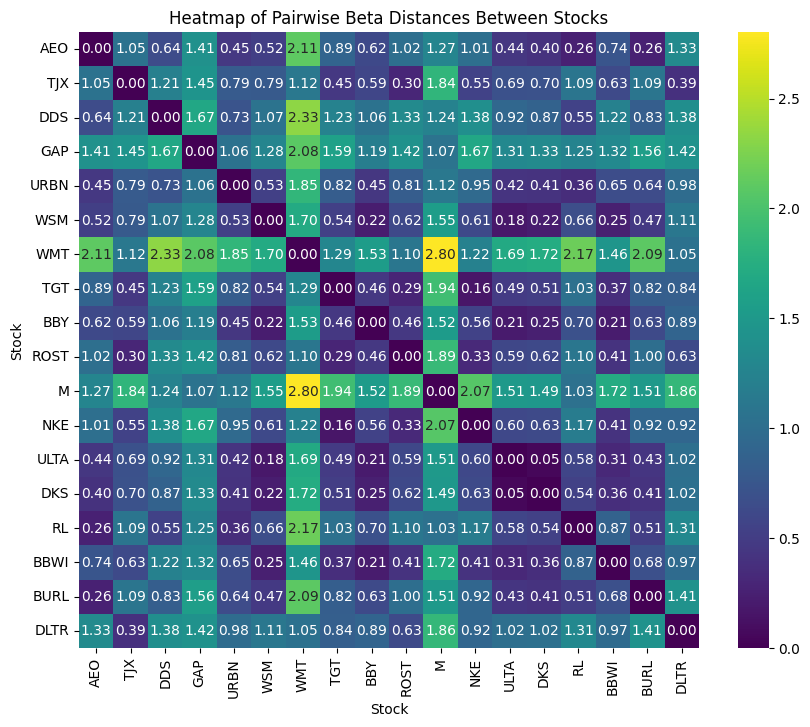

In [ ]:
from scipy.spatial.distance import squareform
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the condensed distance matrix to a squareform distance matrix
distance_matrix = squareform(distances)

# Get stock tickers for labeling the heatmap
stock_tickers = results_df['Stock'].tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    distance_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    xticklabels=stock_tickers,
    yticklabels=stock_tickers
)
plt.title('Heatmap of Pairwise Beta Distances Between Stocks')
plt.xlabel('Stock')
plt.ylabel('Stock')
plt.show()

Darkest color is the lowest distance score, ie best pair.

In [ ]:
"""
Pairs:
TGT & NIKE (0.16)
WSM & ULTA (0.18)
BBWI & BBY (0.21)
WSM & DKS (0.22)
WSM & BBY (0.22)

"""


'\nPairs:\nTGT & NIKE (0.16)\nWSM & ULTA (0.18)\nBBWI & BBY (0.21)\nWSM & DKS (0.22)\nWSM & BBY (0.22)\n\n'

In [ ]:
!pip install alpaca-py --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Alpaca imports
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Regression
import statsmodels.api as sm


# ============================================================
# 0. SETUP ALPACA KEYS
# ============================================================

API_KEY = os.environ.get("ALPACA_API_KEY")  # set in your environment; never commit keys
SECRET_KEY = os.environ.get("ALPACA_SECRET_KEY")
data_client = StockHistoricalDataClient(API_KEY, SECRET_KEY)
trading_client = TradingClient(API_KEY, SECRET_KEY, paper=True)



# ============================================================
# 1. GET HISTORICAL PRICE DATA
# ============================================================
def get_prices(symbols, start, end):
    """
    Downloads daily adjusted close prices from Alpaca
    and returns a pivoted DataFrame.
    """
    request = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
        feed="iex"
    )

    bars = data_client.get_stock_bars(request).df

    # Pivot to wide format: index = date, columns = tickers
    prices = bars['close'].unstack(level=0)
    prices.index = prices.index.date

    return prices



# ============================================================
# 2. MAIN PAIRS TRADE FUNCTION
# ============================================================
def run_pairs_trade_live(stock_A, stock_B, capital_per_leg=10000):

    print(f"\n===== RUNNING PAIRS TRADE: {stock_A} vs {stock_B} =====")

    # Convert dates
    start_date = datetime.now().date()
    lookback_start = start_date - timedelta(days=365)
    end_date = datetime.now()

    # --------------------------------------------------------
    # 2.1 GET PRICE DATA
    # --------------------------------------------------------
    prices = get_prices([stock_A, stock_B], lookback_start, end_date).dropna()
    print(f"Downloaded {len(prices)} days of prices")

    # --------------------------------------------------------
    # 2.2 COMPUTE HEDGE RATIO WITH OLS
    # --------------------------------------------------------
    y = prices[stock_A]
    X = sm.add_constant(prices[stock_B])
    model = sm.OLS(y, X).fit()
    beta = model.params[stock_B]

    print(f"Hedge ratio (beta): {beta:.4f}")

    # --------------------------------------------------------
    # 2.3 COMPUTE SPREAD
    # --------------------------------------------------------
    spread = prices[stock_A] - beta * prices[stock_B]

    # Use only PREVIOUS data for mean/stdev
    hist = spread.iloc[:-1]
    spread_mean = hist.mean()
    spread_std = hist.std()

    # Today's spread
    spread_today = spread.iloc[-1]
    z = (spread_today - spread_mean) / spread_std

    print(f"Spread today: {spread_today:.4f}")
    print(f"Z-score today: {z:.4f}")

    # --------------------------------------------------------
    # 2.4 DETERMINE TRADE DIRECTION
    # --------------------------------------------------------
    if z > 0:
        long_stock = stock_B
        short_stock = stock_A
    else:
        long_stock = stock_A
        short_stock = stock_B

    print(f"LONG  → {long_stock}")
    print(f"SHORT → {short_stock}")

    # --------------------------------------------------------
    # 2.5 GET ENTRY PRICES
    # --------------------------------------------------------
    entry_long_price = prices.iloc[-1][long_stock]
    entry_short_price = prices.iloc[-1][short_stock]

    qty_long = int(capital_per_leg / entry_long_price)
    qty_short = int(capital_per_leg / entry_short_price)

    print(f"Entry {long_stock} price: {entry_long_price:.2f}, qty: {qty_long}")
    print(f"Entry {short_stock} price: {entry_short_price:.2f}, qty: {qty_short}")

    # --------------------------------------------------------
    # 2.6 PLACE LIVE ORDERS ON ALPACA
    # --------------------------------------------------------
    print("\nSubmitting LIVE market orders...")

    # LONG leg
    long_order = MarketOrderRequest(
        symbol=long_stock,
        qty=qty_long,
        side=OrderSide.BUY,
        time_in_force=TimeInForce.DAY
    )
    trading_client.submit_order(long_order)

    # SHORT leg
    short_order = MarketOrderRequest(
        symbol=short_stock,
        qty=qty_short,
        side=OrderSide.SELL,
        time_in_force=TimeInForce.DAY
    )
    trading_client.submit_order(short_order)

    print("\n===== LIVE TRADE EXECUTED SUCCESSFULLY =====")
    print("Now hold this position for 7 days.")
    print("Run your EXIT script on Day 7 to close the pair.\n")

    return {
        "long": long_stock,
        "short": short_stock,
        "long_entry_price": entry_long_price,
        "short_entry_price": entry_short_price,
        "entry_date": start_date
    }

In [ ]:
# to close the positoons at the end of day 7
trading_client.close_position(long_stock)
trading_client.close_position(short_stock)

# calculate the Long and Short PnL
Long_PnL  = qty_long  * (exit_long  - entry_long)
Short_PnL = qty_short * (entry_short - exit_short)

NameError: name 'long_stock' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def backtest_pairs_trade(stock_A, stock_B, prices_df, entry_threshold=1.5, exit_threshold=0.5, window=60):
    """
    Backtests a simple pairs trading strategy.

    Args:
        stock_A (str): Ticker for stock A.
        stock_B (str): Ticker for stock B.
        prices_df (pd.DataFrame): DataFrame with historical prices for both stocks.
        entry_threshold (float): Z-score threshold to enter a trade.
        exit_threshold (float): Z-score threshold to exit a trade.
        window (int): Rolling window for mean and std dev calculation.

    Returns:
        pd.Series: Daily PnL for the strategy (normalized to 1 unit of spread).
    """

    # Ensure prices are available for both stocks and sufficient data for rolling window
    if stock_A not in prices_df.columns or stock_B not in prices_df.columns or prices_df.shape[0] < window:
        return pd.Series(0.0, index=prices_df.index) # Return empty PnL series if data is insufficient

    # Calculate beta over the available historical prices
    # This is a simplification; a true backtest would use a rolling beta.
    y = prices_df[stock_A]
    X = sm.add_constant(prices_df[stock_B])

    # Drop any remaining NaNs to ensure OLS works correctly
    temp_df = pd.DataFrame({'y': y, 'x': prices_df[stock_B]}).dropna()
    if len(temp_df) < 2: # Need at least 2 points for regression
        return pd.Series(0.0, index=prices_df.index)

    model = sm.OLS(temp_df['y'], sm.add_constant(temp_df['x'])).fit()
    beta = model.params['x']

    spread = prices_df[stock_A] - beta * prices_df[stock_B]

    # Calculate rolling mean and standard deviation for the spread, with min_periods to avoid initial NaNs
    rolling_mean = spread.rolling(window=window, min_periods=1).mean()
    rolling_std = spread.rolling(window=window, min_periods=1).std()

    z_scores = (spread - rolling_mean) / rolling_std

    pnl = pd.Series(0.0, index=prices_df.index)
    position = 0 # 0: no position, 1: long spread (long A, short B), -1: short spread (short A, long B)

    # Start trading simulation after the first 'window' period where rolling stats become more stable.
    start_sim_idx = window - 1

    for i in range(start_sim_idx, len(prices_df)):
        current_date = prices_df.index[i]

        current_z = z_scores.iloc[i]

        # If no position, check for entry
        if position == 0:
            if current_z > entry_threshold: # Spread is too high, short spread (short A, long B)
                position = -1
            elif current_z < -entry_threshold: # Spread is too low, long spread (long A, short B)
                position = 1
        # If holding a position, calculate PnL and check for exit
        else:
            # Daily PnL is the change in spread value (assuming 1 unit of spread)
            daily_spread_change = spread.iloc[i] - spread.iloc[i-1]
            if position == 1: # Long spread
                pnl.loc[current_date] = daily_spread_change
            elif position == -1: # Short spread
                pnl.loc[current_date] = -daily_spread_change # PnL is inverse of spread change

            # Check for exit condition (z-score reverts)
            if (position == 1 and current_z >= -exit_threshold) or \
               (position == -1 and current_z <= exit_threshold):
                position = 0 # Exit position

    return pnl

In [ ]:
# --- Backtesting and Plotting Cumulative Returns ---

# Define the backtesting period (e.g., 3 years prior to today)
start_date_backtest = datetime.now().date() - timedelta(days=365*3)
end_date_backtest = datetime.now().date()

# Initialize a dictionary to store PnL for each pair
daily_pnls_per_pair = {}

# The 'pairs' list is defined in a previous cell (XbuhrAptVNIP)
# For each pair, run the backtest
for stock_A, stock_B in pairs:
    print(f"Backtesting {stock_A} vs {stock_B}...")
    try:
        # Retrieve historical prices using the existing get_prices function
        historical_prices = get_prices([stock_A, stock_B], start_date_backtest, end_date_backtest)

        # Ensure enough data is available for the rolling window calculation (e.g., at least 60 days)
        if historical_prices.empty or historical_prices.dropna().shape[0] < 60:
            print(f"Skipping {stock_A}-{stock_B}: Insufficient historical data for backtesting.")
            continue

        # Run the backtest function for the current pair
        pair_pnl_series = backtest_pairs_trade(stock_A, stock_B, historical_prices)

        # Store the PnL series for the pair, reindexing to the full date range to ensure alignment
        if not pair_pnl_series.empty:
            daily_pnls_per_pair[f'{stock_A}-{stock_B}'] = pair_pnl_series.reindex(pd.date_range(start_date_backtest, end_date_backtest), fill_value=0)

    except Exception as e:
        print(f"Error backtesting {stock_A}-{stock_B}: {e}")

# Combine and plot cumulative PnL if backtest data is available
if daily_pnls_per_pair:
    # Get a complete date range for the entire backtest period
    full_date_range = pd.date_range(start_date_backtest, end_date_backtest)

    # Create a DataFrame where each column is the daily PnL of a pair
    combined_pnls_df = pd.DataFrame({
        name: pnl_series.reindex(full_date_range, fill_value=0)
        for name, pnl_series in daily_pnls_per_pair.items()
    })

    # Sum the PnL across all pairs for each day to get the total daily PnL of the strategy
    total_daily_pnl = combined_pnls_df.sum(axis=1)

    # Calculate the cumulative PnL
    cumulative_pnl = total_daily_pnl.cumsum()

    # Plot the cumulative PnL
    plt.figure(figsize=(14, 7))
    plt.plot(cumulative_pnl)
    plt.title('Cumulative PnL of Pairs Trading Strategy (Backtest)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative PnL (Spread Units)') # Units are spread value changes
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
    plt.tight_layout()
    plt.show()
else:
    print("No PnL data generated for plotting cumulative returns after backtesting all pairs.")

NameError: name 'pairs' is not defined

In [ ]:
# --- Calculate Sharpe Ratio for Individual Pairs ---
print("\nSharpe Ratios for Individual Pairs (Annualized):")
sharpe_ratios_pairs = {}
annualization_factor = np.sqrt(252) # Assuming 252 trading days in a year

for pair_name, pnl_series in daily_pnls_per_pair.items():
    # The PnL series already represents returns in spread units
    # Ensure non-zero standard deviation to avoid division by zero
    if pnl_series.std() != 0:
        # Assuming a risk-free rate of 0 for simplicity in this context
        daily_sharpe = pnl_series.mean() / pnl_series.std()
        annualized_sharpe = daily_sharpe * annualization_factor
        sharpe_ratios_pairs[pair_name] = annualized_sharpe
        print(f"  {pair_name}: {annualized_sharpe:.4f}")
    else:
        print(f"  {pair_name}: Cannot calculate Sharpe Ratio (zero standard deviation)")

# --- Calculate Sharpe Ratio for the Entire Portfolio ---
print("\nSharpe Ratio for the Entire Portfolio (Annualized):")
if total_daily_pnl.std() != 0:
    # Assuming a risk-free rate of 0 for simplicity in this context
    portfolio_daily_sharpe = total_daily_pnl.mean() / total_daily_pnl.std()
    portfolio_annualized_sharpe = portfolio_daily_sharpe * annualization_factor
    print(f"  Overall Portfolio: {portfolio_annualized_sharpe:.4f}")
else:
    print("  Overall Portfolio: Cannot calculate Sharpe Ratio (zero standard deviation)")


Sharpe Ratios for Individual Pairs (Annualized):

Sharpe Ratio for the Entire Portfolio (Annualized):


NameError: name 'total_daily_pnl' is not defined

In [ ]:
"""
Run the code using the top 5 pairs
"""
pairs = [
    ("TGT", "NKE"),
    ("WSM", "ULTA"),
    ("BBWI", "BBY"),
    ("AEO", "BURL"),
    ("ROST", "TJX")
]

results = []

for stock_A, stock_B in pairs:
    info = run_pairs_trade_live(stock_A, stock_B, capital_per_leg=10000)
    results.append(info)


===== RUNNING PAIRS TRADE: TGT vs NKE =====
Downloaded 250 days of prices
Hedge ratio (beta): 1.3394
Spread today: 4.0703
Z-score today: -0.6253
LONG  → TGT
SHORT → NKE
Entry TGT price: 90.62, qty: 110
Entry NKE price: 64.62, qty: 154

Submitting LIVE market orders...

===== LIVE TRADE EXECUTED SUCCESSFULLY =====
Now hold this position for 7 days.
Run your EXIT script on Day 7 to close the pair.


===== RUNNING PAIRS TRADE: WSM vs ULTA =====
Downloaded 250 days of prices
Hedge ratio (beta): 0.1016
Spread today: 125.2604
Z-score today: -0.6350
LONG  → WSM
SHORT → ULTA
Entry WSM price: 180.01, qty: 55
Entry ULTA price: 539.12, qty: 18

Submitting LIVE market orders...


APIError: {"buying_power":"8255.77","code":40310000,"cost_basis":"9901.94","message":"insufficient buying power"}

/tmp/ipykernel_7604/4244581414.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  volatility_prices = yf.download(volatility_tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_7604/4244581414.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = volatility_prices.pct_change().dropna()


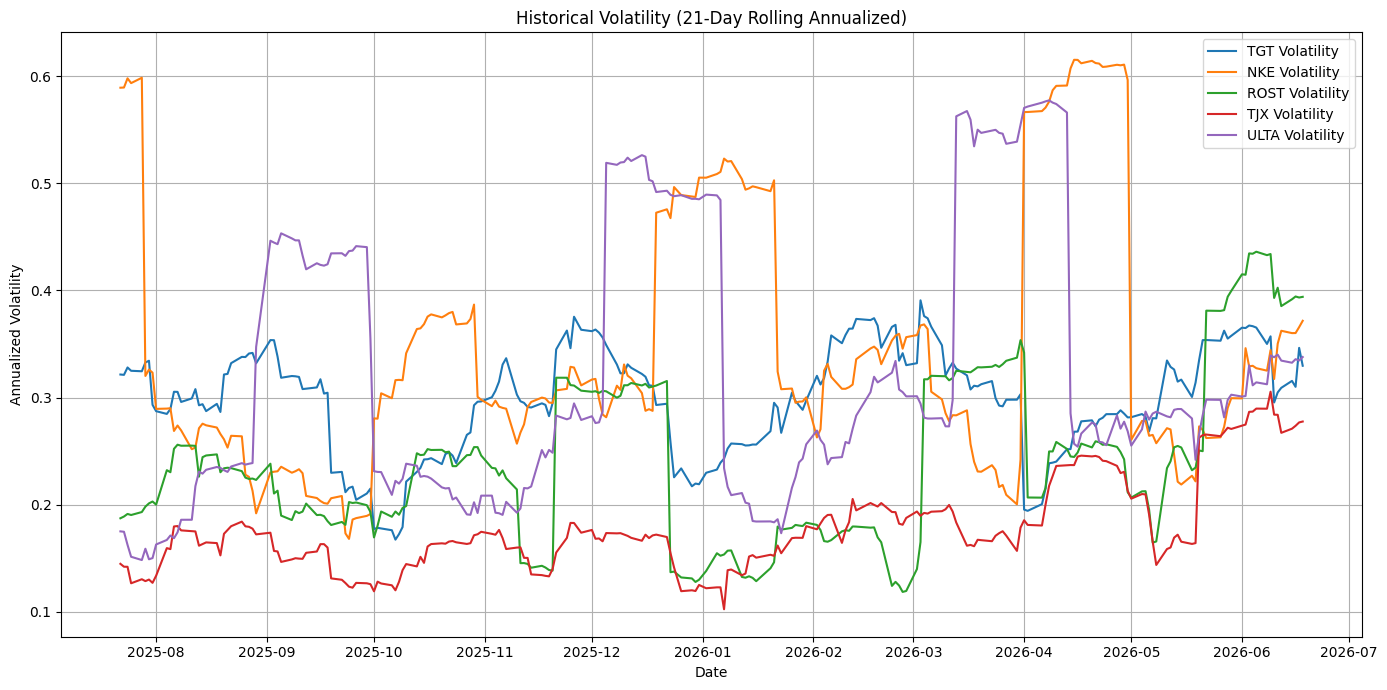

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf # Import yfinance
from datetime import datetime, timedelta

# Define the tickers for the volatility graph
volatility_tickers = ['TGT', 'NKE', 'ROST', 'TJX', 'ULTA']

# Define the date range for historical data (e.g., last 5 years)
end_date = datetime.now().date()
start_date = end_date - timedelta(days=365 * 1) # 5 years lookback

# Get historical prices for the selected tickers using yfinance
volatility_prices = yf.download(volatility_tickers, start=start_date, end=end_date)['Close']

# Calculate daily returns
daily_returns = volatility_prices.pct_change().dropna()

# Calculate rolling 21-day (approx. 1 month) historical volatility
# Annualize by multiplying by the square root of 252 (trading days in a year)
rolling_volatility = daily_returns.rolling(window=21).std() * np.sqrt(252)

# Plot the historical volatility
plt.figure(figsize=(14, 7))
for ticker in volatility_tickers:
    plt.plot(rolling_volatility[ticker], label=f'{ticker} Volatility')

plt.title('Historical Volatility (21-Day Rolling Annualized)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()